# RetailPulse: AI-Powered Sales & Retail Analytics Platform
## Day 3 — Customer Segmentation (K-Means + DBSCAN)

**Module:** Customer Segmentation & Churn Prediction (Phase 2 continued)

**Requirement (F-02):** RFM + behavioral segmentation using K-Means / DBSCAN, producing 6–8 meaningful segments with business interpretation.

Uses `data/processed/rfm_features.csv` from Day 2.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score

PROCESSED_DIR = "../data/processed"
REPORTS_DIR = "../reports"

rfm = pd.read_csv(f"{PROCESSED_DIR}/rfm_features.csv")
print(f"Customers: {len(rfm):,}")
rfm.head()

Customers: 4,955


,CustomerID,Recency,Frequency,Monetary,AvgOrderValue,TenureDays,PurchaseFreqPerMonth
0,100000,103,24,26994.90,1124.787500,444,1.621622
1,100001,6,29,26606.02,917.448966,206,4.223301
2,100002,43,2,1475.26,737.630000,18,3.333333
3,100003,13,114,118761.52,1041.767719,713,4.796634
4,100004,44,17,14329.41,842.906471,507,1.005917


## 1. Preprocessing

RFM distributions are heavily right-skewed (Monetary especially), so apply a log1p transform before scaling — this keeps K-Means from being dominated by a handful of very high-spend outliers.

In [2]:
features = ["Recency", "Frequency", "Monetary"]

rfm_log = rfm[features].apply(lambda x: np.log1p(x))

scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_log)
rfm_scaled = pd.DataFrame(rfm_scaled, columns=features, index=rfm.index)
rfm_scaled.describe().round(2)

,Recency,Frequency,Monetary
count,4955.00,4955.00,4955.00
mean,0.00,0.00,0.00
std,1.00,1.00,1.00
min,-1.59,-2.32,-5.83
25%,-0.89,-0.71,-0.60
50%,-0.10,0.03,0.10
75%,1.00,0.77,0.76
max,1.63,2.06,1.83


## 2. K-Means — Choosing k (Elbow + Silhouette)

/Users/mulkitsain/Downloads/New project/Claude code files/files/RetailPulse/venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/mulkitsain/Downloads/New project/Claude code files/files/RetailPulse/venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/mulkitsain/Downloads/New project/Claude code files/files/RetailPulse/venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/mulkitsain/Downloads/New project/Claude code files/files/RetailPulse/venv/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: divide by zero encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/Users/mulkitsain/Downloads/New project/Claude code files/files/RetailPulse/venv/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:237: R

/Users/mulkitsain/Downloads/New project/Claude code files/files/RetailPulse/venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/mulkitsain/Downloads/New project/Claude code files/files/RetailPulse/venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/mulkitsain/Downloads/New project/Claude code files/files/RetailPulse/venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/mulkitsain/Downloads/New project/Claude code files/files/RetailPulse/venv/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: divide by zero encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/Users/mulkitsain/Downloads/New project/Claude code files/files/RetailPulse/venv/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:237: R

/Users/mulkitsain/Downloads/New project/Claude code files/files/RetailPulse/venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/mulkitsain/Downloads/New project/Claude code files/files/RetailPulse/venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/mulkitsain/Downloads/New project/Claude code files/files/RetailPulse/venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/mulkitsain/Downloads/New project/Claude code files/files/RetailPulse/venv/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: divide by zero encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/Users/mulkitsain/Downloads/New project/Claude code files/files/RetailPulse/venv/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:237: R

/Users/mulkitsain/Downloads/New project/Claude code files/files/RetailPulse/venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/mulkitsain/Downloads/New project/Claude code files/files/RetailPulse/venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/mulkitsain/Downloads/New project/Claude code files/files/RetailPulse/venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/mulkitsain/Downloads/New project/Claude code files/files/RetailPulse/venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/mulkitsain/Downloads/New project/Claude code files/files/RetailPulse/venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in

/Users/mulkitsain/Downloads/New project/Claude code files/files/RetailPulse/venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/mulkitsain/Downloads/New project/Claude code files/files/RetailPulse/venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/mulkitsain/Downloads/New project/Claude code files/files/RetailPulse/venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/mulkitsain/Downloads/New project/Claude code files/files/RetailPulse/venv/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: divide by zero encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/Users/mulkitsain/Downloads/New project/Claude code files/files/RetailPulse/venv/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:237: R

/Users/mulkitsain/Downloads/New project/Claude code files/files/RetailPulse/venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/mulkitsain/Downloads/New project/Claude code files/files/RetailPulse/venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/mulkitsain/Downloads/New project/Claude code files/files/RetailPulse/venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/mulkitsain/Downloads/New project/Claude code files/files/RetailPulse/venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/mulkitsain/Downloads/New project/Claude code files/files/RetailPulse/venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in

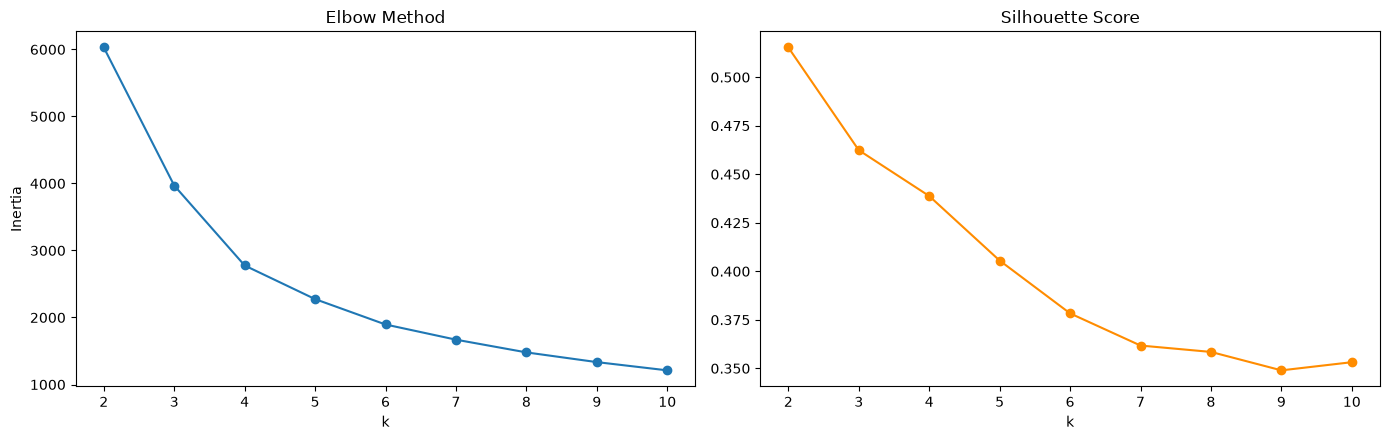

Best k by silhouette score: 2


In [3]:
inertias, sil_scores = [], []
k_range = range(2, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(rfm_scaled)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(rfm_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
axes[0].plot(list(k_range), inertias, marker="o")
axes[0].set_title("Elbow Method"); axes[0].set_xlabel("k"); axes[0].set_ylabel("Inertia")

axes[1].plot(list(k_range), sil_scores, marker="o", color="darkorange")
axes[1].set_title("Silhouette Score"); axes[1].set_xlabel("k")

plt.tight_layout()
plt.savefig(f"{REPORTS_DIR}/day3_kmeans_k_selection.png", dpi=120, bbox_inches="tight")
plt.show()

best_k = list(k_range)[int(np.argmax(sil_scores))]
print(f"Best k by silhouette score: {best_k}")

## 3. Fit K-Means at k=6

Business requirement is 6–8 segments — fixing k=6 here (adjust if the silhouette curve above suggests otherwise for your data draw) balances interpretability against granularity.

In [4]:
K = 6
kmeans = KMeans(n_clusters=K, random_state=42, n_init=10)
rfm["Cluster_KMeans"] = kmeans.fit_predict(rfm_scaled)

sil = silhouette_score(rfm_scaled, rfm["Cluster_KMeans"])
print(f"Silhouette score @ k={K}: {sil:.3f}")
rfm["Cluster_KMeans"].value_counts().sort_index()

Silhouette score @ k=6: 0.378


/Users/mulkitsain/Downloads/New project/Claude code files/files/RetailPulse/venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/mulkitsain/Downloads/New project/Claude code files/files/RetailPulse/venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/mulkitsain/Downloads/New project/Claude code files/files/RetailPulse/venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/mulkitsain/Downloads/New project/Claude code files/files/RetailPulse/venv/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: divide by zero encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/Users/mulkitsain/Downloads/New project/Claude code files/files/RetailPulse/venv/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:237: R

Cluster_KMeans
0    1049
1     889
2     492
3     538
4    1052
5     935
Name: count, dtype: int64

## 4. Business Interpretation of Segments

Rank clusters by mean Monetary value and Recency to assign human-readable segment names, rather than hard-coding cluster-index → label mappings (K-Means cluster indices are arbitrary and can shift between runs).

In [5]:
cluster_profile = (rfm.groupby("Cluster_KMeans")[features]
                    .mean()
                    .round(1)
                    .assign(Count=rfm["Cluster_KMeans"].value_counts())
                    .sort_values("Monetary", ascending=False))
cluster_profile

,Recency,Frequency,Monetary,Count
Cluster_KMeans,,,,
4,6.8,77.2,72483.1,1052
0,11.6,33.5,31783.7,1049
1,282.0,21.9,20788.6,889
3,12.7,12.6,11699.1,538
5,236.3,7.8,7235.7,935
2,156.2,2.6,2028.3,492


In [6]:
def label_segment(row):
    if row["Monetary"] >= cluster_profile["Monetary"].quantile(0.8) and row["Recency"] <= cluster_profile["Recency"].median():
        return "Champions"
    if row["Frequency"] >= cluster_profile["Frequency"].median() and row["Recency"] <= cluster_profile["Recency"].median():
        return "Loyal Customers"
    if row["Recency"] <= cluster_profile["Recency"].quantile(0.3):
        return "Recent / New"
    if row["Recency"] >= cluster_profile["Recency"].quantile(0.7) and row["Monetary"] >= cluster_profile["Monetary"].median():
        return "At Risk"
    if row["Recency"] >= cluster_profile["Recency"].quantile(0.7):
        return "Hibernating"
    return "Needs Attention"

cluster_profile["SegmentLabel"] = cluster_profile.apply(label_segment, axis=1)
label_map = cluster_profile["SegmentLabel"].to_dict()
rfm["Segment"] = rfm["Cluster_KMeans"].map(label_map)

cluster_profile

,Recency,Frequency,Monetary,Count,SegmentLabel
Cluster_KMeans,,,,,
4,6.8,77.2,72483.1,1052,Champions
0,11.6,33.5,31783.7,1049,Champions
1,282.0,21.9,20788.6,889,At Risk
3,12.7,12.6,11699.1,538,Needs Attention
5,236.3,7.8,7235.7,935,Hibernating
2,156.2,2.6,2028.3,492,Needs Attention


## 5. Cluster Visualization

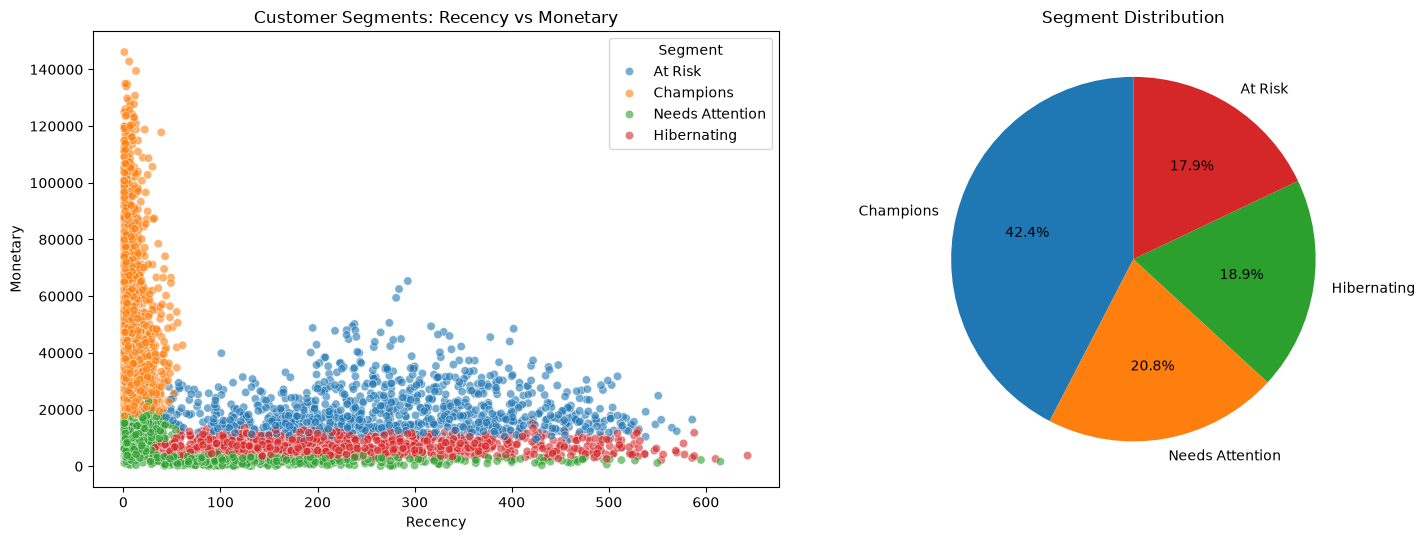

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

sns.scatterplot(data=rfm, x="Recency", y="Monetary", hue="Segment",
                palette="tab10", alpha=0.6, ax=axes[0])
axes[0].set_title("Customer Segments: Recency vs Monetary")

segment_counts = rfm["Segment"].value_counts()
axes[1].pie(segment_counts, labels=segment_counts.index, autopct="%1.1f%%", startangle=90)
axes[1].set_title("Segment Distribution")

plt.tight_layout()
plt.savefig(f"{REPORTS_DIR}/day3_segments.png", dpi=120, bbox_inches="tight")
plt.show()

## 6. DBSCAN — Density-Based Alternative

DBSCAN doesn't require specifying the number of clusters upfront and can flag outlier customers (label `-1`) that K-Means would otherwise force into a segment. Used here as a cross-check on the K-Means result, per the F-02 requirement to support both algorithms.

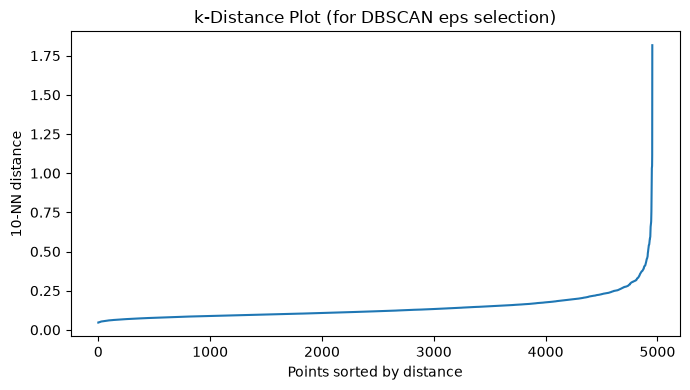

eps guess (90th percentile of k-distances): 0.222


In [8]:
from sklearn.neighbors import NearestNeighbors

# k-distance plot to pick eps (k = min_samples)
min_samples = 10
neighbors = NearestNeighbors(n_neighbors=min_samples).fit(rfm_scaled)
distances, _ = neighbors.kneighbors(rfm_scaled)
k_distances = np.sort(distances[:, -1])

plt.figure(figsize=(7, 4))
plt.plot(k_distances)
plt.title("k-Distance Plot (for DBSCAN eps selection)")
plt.xlabel("Points sorted by distance"); plt.ylabel(f"{min_samples}-NN distance")
plt.tight_layout()
plt.savefig(f"{REPORTS_DIR}/day3_dbscan_kdistance.png", dpi=120, bbox_inches="tight")
plt.show()

# elbow of the k-distance curve is a reasonable eps starting point
eps_guess = float(np.percentile(k_distances, 90))
print(f"eps guess (90th percentile of k-distances): {eps_guess:.3f}")

In [9]:
dbscan = DBSCAN(eps=eps_guess, min_samples=min_samples)
rfm["Cluster_DBSCAN"] = dbscan.fit_predict(rfm_scaled)

n_clusters = len(set(rfm["Cluster_DBSCAN"])) - (1 if -1 in rfm["Cluster_DBSCAN"].values else 0)
n_noise = (rfm["Cluster_DBSCAN"] == -1).sum()
print(f"DBSCAN clusters found: {n_clusters}")
print(f"Noise / outlier points: {n_noise:,} ({n_noise/len(rfm)*100:.1f}%)")
rfm["Cluster_DBSCAN"].value_counts().sort_index()

DBSCAN clusters found: 6
Noise / outlier points: 259 (5.2%)


Cluster_DBSCAN
-1     259
 0    4141
 1     297
 2     127
 3      89
 4      15
 5      27
Name: count, dtype: int64

## 7. Persist Segmented Customer Table

In [10]:
rfm.to_csv(f"{PROCESSED_DIR}/customer_segments.csv", index=False)
print(f"Saved: customer_segments.csv ({len(rfm):,} rows)")
rfm[["CustomerID", "Recency", "Frequency", "Monetary", "Cluster_KMeans", "Segment", "Cluster_DBSCAN"]].head(10)

Saved: customer_segments.csv (4,955 rows)


,CustomerID,Recency,Frequency,Monetary,Cluster_KMeans,Segment,Cluster_DBSCAN
0,100000,103,24,26994.90,1,At Risk,0
1,100001,6,29,26606.02,0,Champions,0
2,100002,43,2,1475.26,2,Needs Attention,3
3,100003,13,114,118761.52,4,Champions,0
4,100004,44,17,14329.41,3,Needs Attention,0
5,100005,236,7,8210.47,5,Hibernating,0
6,100006,38,41,38858.23,0,Champions,0
7,100007,6,25,22937.77,0,Champions,0
8,100008,8,23,27279.37,0,Champions,0
9,100009,8,50,49943.70,4,Champions,0


## 8. Day 3 Checkpoint Summary

**Outputs saved:**
- `data/processed/customer_segments.csv` — RFM + K-Means cluster + business segment label + DBSCAN cluster
- `reports/day3_kmeans_k_selection.png`, `day3_segments.png`, `day3_dbscan_kdistance.png`

**Segments produced (K-Means, k=6):** business-labeled via Recency/Monetary ranking — Champions, Loyal Customers, Recent/New, At Risk, Hibernating, Needs Attention.

**DBSCAN** used as a cross-check — flags density outliers K-Means would force into a cluster.

**Next module:** `03b_churn_prep` or `04_timeseries_prep` — depending on whether we do churn labeling next or move straight to demand forecasting data prep.